# Capability 03 — Event memory

Executed evidence over in-memory seed facts. The notebook is the experiment surface; runtime services stay in `src/telco_digital`. Results do not establish production retrieval quality.

In [1]:
from pathlib import Path
import asyncio, json
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
from telco_digital.application.clock import FixedClock
from telco_digital.application.seed import seed_demo_customers
from telco_digital.infrastructure.memory import InMemoryUnitOfWork
from telco_digital.intelligence.event_memory import EventMemoryService
from telco_digital.intelligence.event_memory.uow import UnitOfWorkEventMemoryQueries

ROOT = Path("outputs")
for folder in ("tables", "plots", "artifacts"):
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
AUGUST = datetime.fromisoformat("2026-08-20T12:00:00+00:00")
DURING = datetime.fromisoformat("2026-03-16T12:00:00+00:00")

async def recall():
    uow = InMemoryUnitOfWork()
    await seed_demo_customers(uow, clock=FixedClock(datetime.fromisoformat("2026-08-27T00:00:00+00:00")))
    service = EventMemoryService(UnitOfWorkEventMemoryQueries(uow))
    return await service.recall("U001", AUGUST, destination="SG"), await service.recall("U001", DURING)

august, during = await recall()
episode = august.historical_episodes[0]
top = august.matches[0]
len(august.historical_episodes), len(august.matches)

(1, 1)

In [2]:
leakage_ok = during.current_situation.duration_known is False
metrics = {
    "episode_set_version": august.episode_set_version,
    "synthetic_poc": True,
    "u001_march_duration_days": episode.duration_days,
    "u001_march_usage_gb": episode.metrics["usage_gb"],
    "u001_march_plan": episode.actions["plan_selected"],
    "u001_march_outcome": episode.outcome,
    "august_top_rank": top.rank.value,
    "august_top_similarity": top.similarity,
    "future_leakage_checks_failed": 0 if leakage_ok else 1,
    "historical_episode_count": len(august.historical_episodes),
    "match_count": len(august.matches),
}
(ROOT / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n", encoding="utf-8")
assert episode.duration_days == 6
assert episode.metrics["usage_gb"] == 11.4
assert episode.actions["plan_selected"] == "ROAM_15"
assert episode.outcome == "No additional package required"
assert leakage_ok
assert during.current_situation.destination == "SG"
metrics

{'episode_set_version': 'travel-episodes-v1',
 'synthetic_poc': True,
 'u001_march_duration_days': 6,
 'u001_march_usage_gb': 11.4,
 'u001_march_plan': 'ROAM_15',
 'u001_march_outcome': 'No additional package required',
 'august_top_rank': 'SAME_CUSTOMER_SAME_SITUATION',
 'august_top_similarity': 0.95,
 'future_leakage_checks_failed': 0,
 'historical_episode_count': 1,
 'match_count': 1}

In [3]:
march = {
    "destination": episode.destination_name,
    "start_at": episode.start_at.isoformat(),
    "end_at": episode.end_at.isoformat() if episode.end_at else None,
    "duration_days": episode.duration_days,
    "usage_gb": episode.metrics["usage_gb"],
    "plan_selected": episode.actions["plan_selected"],
    "outcome": episode.outcome,
}
ranks = [
    {
        "customer_ref": item.episode.customer_ref,
        "destination": item.episode.destination_name,
        "rank": item.rank.value,
        "similarity": item.similarity,
    }
    for item in august.matches
]
leakage = {
    "as_of": DURING.isoformat(),
    "destination": during.current_situation.destination,
    "duration_known": during.current_situation.duration_known,
    "current_travel_excluded_from_history": len(during.historical_episodes) == 0,
    "failed": 0 if leakage_ok else 1,
}
(ROOT / "tables" / "u001_march_episode.json").write_text(json.dumps(march, indent=2) + "\n", encoding="utf-8")
(ROOT / "tables" / "match_ranks.json").write_text(json.dumps(ranks, indent=2) + "\n", encoding="utf-8")
(ROOT / "tables" / "future_leakage_validation.json").write_text(json.dumps(leakage, indent=2) + "\n", encoding="utf-8")
pd.DataFrame(ranks)

,customer_ref,destination,rank,similarity
0,U001,Singapore,SAME_CUSTOMER_SAME_SITUATION,0.95


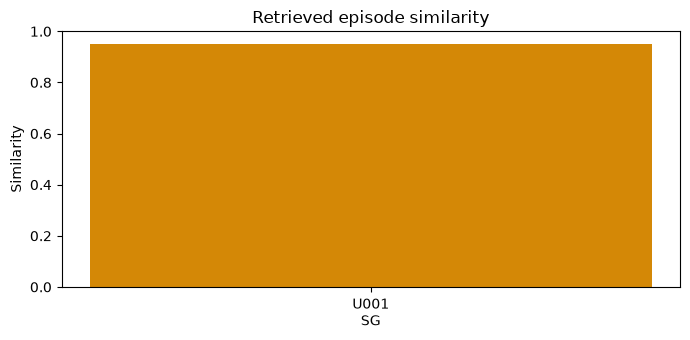

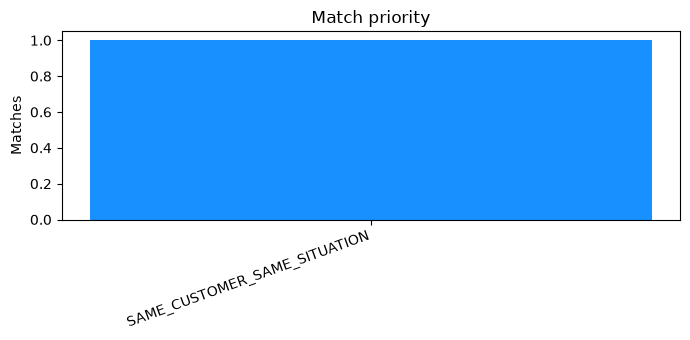

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(
    [f"{item.episode.customer_ref}\n{item.episode.destination}" for item in august.matches],
    [item.similarity for item in august.matches],
    color="#d48806",
)
ax.set_ylim(0, 1)
ax.set_ylabel("Similarity")
ax.set_title("Retrieved episode similarity")
fig.tight_layout()
fig.savefig(ROOT / "plots" / "episode_similarity.png", dpi=120)
plt.show()

rank_counts = pd.Series([item.rank.value for item in august.matches]).value_counts()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(rank_counts.index, rank_counts.values, color="#1890ff")
ax.set_ylabel("Matches")
ax.set_title("Match priority")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(ROOT / "plots" / "match_priority.png", dpi=120)
plt.show()